## Imports

In [3]:
import numpy as np
import fitsio
import time
import pandas as pd
import matplotlib.pyplot as plt
from iminuit import Minuit
from scipy.optimize import minimize
from scipy.optimize import least_squares
from iminuit.cost import LeastSquares
from scipy.optimize import fsolve
from scipy.interpolate import CubicSpline
from astropy.io import fits
from astropy.table import Table
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.stats import binned_statistic 
import os
import glob
import sys
import random
from pathlib import Path
from datetime import datetime
from collections import defaultdict


# from scripts/convert_to_quickquasars_format import convert_transmission_to_quickquasars

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from scripts.convert_to_quickquasars_format import (
    convert_transmission_to_quickquasars
)


# Colorblind friendly colors
CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00', 
                  '#000000', '#FFFFFF']

%matplotlib inline

# select a target redshift
target_redshift = 2.8
safe_z = str(target_redshift).replace('.', '-')


## Sample EDR Catalog for Metadata

In [94]:
### Define a catalog to sample from ###
EDR_cat = '/pscratch/sd/m/mherbold/tests/P1D_Mocks/QQ_int/QSO_cat_fuji_healpix_only_qso_targets.fits'
fname = EDR_cat

with fitsio.FITS(fname) as f:
    cat = f[1].read(columns=[
        "TARGETID",
        "Z",
        "TARGET_RA",
        "TARGET_DEC"
    ])

zmin, zmax = 2.0, 3.8
dz = 0.2

# Number of bins
nbins = int(round((zmax - zmin) / dz))

# Bin centers (2.0, 2.2, ..., 3.8)
z_bins = zmin + dz * np.arange(nbins + 1)
z_bins = np.round(z_bins, 1)


def z_to_bin_index(z, zmin=2.0, dz=0.2):
    """
    Convert redshift to nearest bin index using stable rounding.
    """
    return np.floor((z - zmin) / dz + 0.5).astype(int)


z_idx = z_to_bin_index(cat["Z"], zmin=zmin, dz=dz)
valid = (z_idx >= 0) & (z_idx <= nbins)

cat = cat[valid]
z_idx = z_idx[valid]


N_per_bin = 10
rows = []
rows_zidx = []   # <-- NEW
rng = np.random.default_rng(seed=123)

for i in range(nbins + 1):
    m = z_idx == i
    if m.sum() < N_per_bin:
        continue

    chosen = rng.choice(np.where(m)[0], size=N_per_bin, replace=False)
    rows.append(cat[chosen])
    rows_zidx.append(z_idx[chosen])   # <-- NEW


rows = np.concatenate(rows)
rows_zidx = np.concatenate(rows_zidx)   # <-- NEW

sample = pd.DataFrame({
    "targetid": rows["TARGETID"],
    "ra": rows["TARGET_RA"],
    "dec": rows["TARGET_DEC"],
    "z": rows["Z"],
    "z_bin_index": rows_zidx,                 # <-- NEW (authoritative)
    "z_bin": zmin + dz * rows_zidx             # <-- derived, safe
})

sample["z_bin"] = sample["z_bin"].round(1)


sample

,targetid,ra,dec,z,z_bin_index,z_bin
0,39633321881242040,180.718698,54.902772,2.056222,0,2.0
1,39633561216615587,142.280845,82.307303,1.938920,0,2.0
2,39628454571803852,194.028647,28.726366,1.930988,0,2.0
3,39627860859684256,217.805148,2.911407,1.929023,0,2.0
4,39627773291007151,38.341775,-0.609805,1.986921,0,2.0
...,...,...,...,...,...,...
95,39633267653083173,213.852510,51.253511,3.755028,9,3.8
96,39627921014392921,210.721667,5.449592,3.763445,9,3.8
97,39628234127577265,242.391416,18.703977,3.790552,9,3.8
98,39628222417080702,227.511422,18.250910,3.803507,9,3.8


## Open / Read transmission file

In [2]:
test_file = '/pscratch/sd/m/mherbold/tests/P1D_Mocks/transmission_files/2-8/transmission_2-8_20251103_210325_6568.fits'
fitsio.FITS(test_file)


  file: /pscratch/sd/m/mherbold/tests/P1D_Mocks/transmission_files/2-8/transmission_2-8_20251103_210325_6568.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      TRANSMISSION

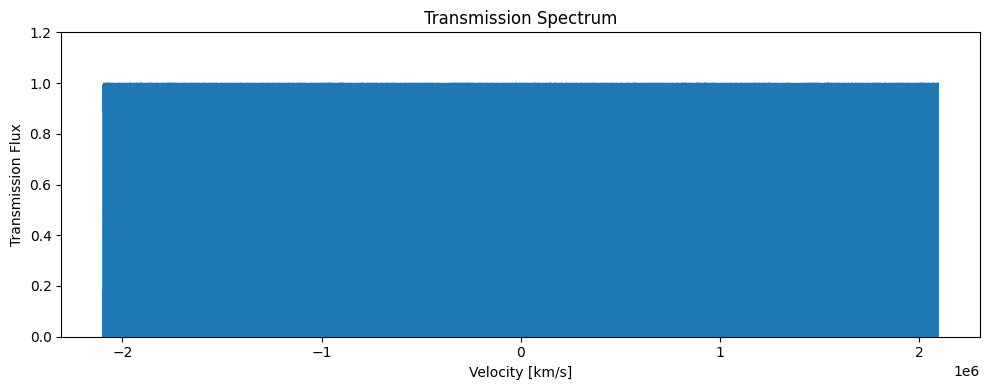

In [30]:
# Path to your FITS file
fits_path = test_file

# Open FITS file and read the TRANSMISSION extension
with fitsio.FITS(fits_path, "r") as f:
    data = f["TRANSMISSION"].read()

velocity = data["VELOCITY"]   # typically km/s
flux     = data["FLUX"]       # transmission flux

# Plot
plt.figure(figsize=(10, 4))
plt.plot(velocity, flux, lw=0.5)
plt.xlabel("Velocity [km/s]")
plt.ylabel("Transmission Flux")
plt.title("Transmission Spectrum")
plt.ylim(0, 1.2)
plt.tight_layout()
plt.show()


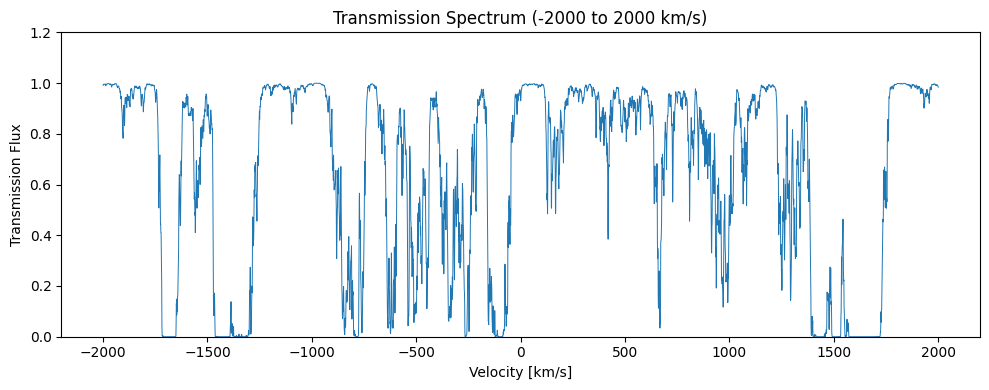

Velocity range: -2097152.0 2097151.0
Flux range: 0.0 0.9999997
Mean flux: 0.7325522


In [34]:
vmin, vmax = -2000, 2000  # km/s

mask = (velocity >= vmin) & (velocity <= vmax)

plt.figure(figsize=(10, 4))
plt.plot(velocity[mask], flux[mask], lw=0.7)
plt.xlabel("Velocity [km/s]")
plt.ylabel("Transmission Flux")
plt.title(f"Transmission Spectrum ({vmin} to {vmax} km/s)")
plt.ylim(0, 1.2)
plt.tight_layout()
plt.show()

print("Velocity range:", velocity.min(), velocity.max())
print("Flux range:", flux.min(), flux.max())
print("Mean flux:", flux.mean())


## Compatibility script (single transmission file)

Note, the following are REQUIRED by quickquasars 

| Name | Type | Description |
|------------|----------|------|
|  Metadata   |  BinTableHDU     |  Metadata of the mock QSOs (see table 6).    |
|  wavelength |  ImageHDU        |  Wavelength λ of the transmitted flux in angstroms.    |
|  F_Lya      |  ImageHDU        | Lyman-α absorptions transmitted flux. Can also be called TRANSMISSION.     |

The following are OPTIONAL:

| Name | Type | Description |
|------------|----------|------|
|  F_lyb      |  ImageHDU        |  Lyman-β absorptions transmitted flux. Optional.    |
|  F_metals   |  ImageHDU        |  Metal absorptions transmitted flux. Optional.    |
|  DLA        |  BinTableHDU     |  Metadata of the correlated DLAs (see table 6). Optional.    |

(see: https://iopscience.iop.org/article/10.1088/1475-7516/2025/01/141)


METADATA

| Name | Format | Description |
|------------|----------|------|
|  RA        |  Float     |  Right Ascension in degrees.    |
|  DEC       |  Float     |  Declination in degrees.        |
|  Z_noRSD   |  Float     |  Redshift without RSD effects   |
|  Z         |  Float     |  Redshift                       |
|  MOCKID    |  Int       |  Mock QSO identification number |


✓ Found input file: /pscratch/sd/m/mherbold/tests/P1D_Mocks/transmission_files/2-8/transmission_2-8_20251103_205009_4977.fits

FITS file structure:
Filename: /pscratch/sd/m/mherbold/tests/P1D_Mocks/transmission_files/2-8/transmission_2-8_20251103_205009_4977.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   ()      
  1  TRANSMISSION    1 BinTableHDU     14   4194304R x 2C   [E, E]   

Primary header info:
  CREATED: 2025-11-03T20:50:09Z
  ZSAFE: 2-8
  LAM0: 1216
  DV: 1.0
  AUTHOR: mock_gen.py

Data shape: velocity=(4194304,), transmission=(4194304,)
Columns:  VELOCITY [km/s], FLUX

First few rows:
VELOCITY (km/s)      FLUX           
-----------------------------------
-2097152.00          0.988587       
-2097151.00          0.990105       
-2097150.00          0.989934       
-2097149.00          0.984554       
-2097148.00          0.982323       

Velocity range: -2097152.0 to 2097151.0 km/s
Transmission range: 0.0000 to 

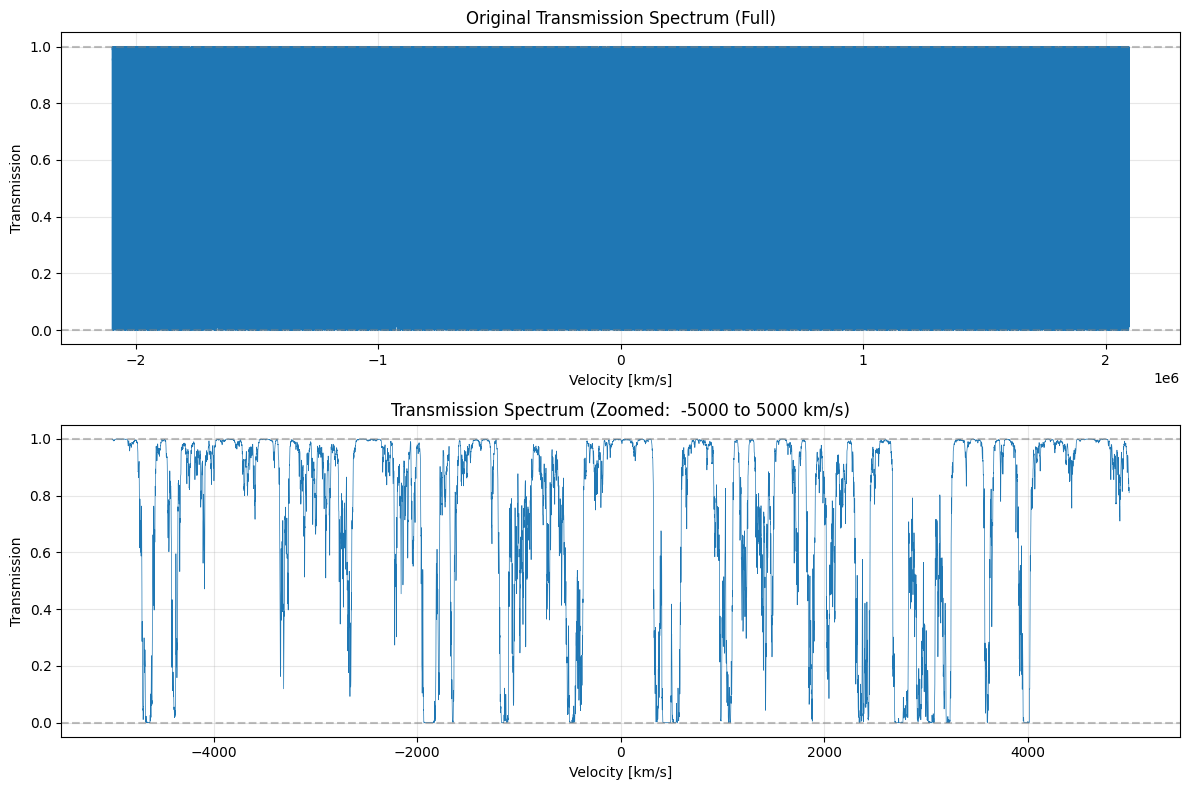


Mean transmission: 0.7321


In [7]:
# 1. CHECK YOUR INPUT TRANSMISSION FILE
# ============================================================================

sys.path.append('.')

# Path to your transmission file - UPDATE THIS!  
base_path = '/pscratch/sd/m/mherbold/tests/P1D_Mocks/transmission_files/'
redshift = '2-8'
input_file = base_path + redshift + '/transmission_2-8_20251103_205009_4977.fits'

# Check if file exists
if Path(input_file).exists():
    print(f"✓ Found input file: {input_file}")
else:
    print(f"✗ File not found: {input_file}")
    print("\nPlease update the path above to your actual transmission file.")

# Load and inspect the transmission FITS file
with fits.open(input_file) as hdul:
    print("\nFITS file structure:")
    hdul.info()
    
    # Read the TRANSMISSION table
    trans_table = Table.read(hdul['TRANSMISSION'])
    velocity = np.array(trans_table['VELOCITY'])
    transmission = np.array(trans_table['FLUX'])
    
    # Read metadata from primary header
    primary_header = hdul[0].header
    print("\nPrimary header info:")
    for key in ['CREATED', 'ZSAFE', 'LAM0', 'DV', 'AUTHOR']: 
        if key in primary_header:
            print(f"  {key}: {primary_header[key]}")

print(f"\nData shape: velocity={velocity.shape}, transmission={transmission. shape}")
print(f"Columns:  VELOCITY [km/s], FLUX")
print(f"\nFirst few rows:")
print(f"{'VELOCITY (km/s)':<20} {'FLUX':<15}")
print("-" * 35)
for i in range(5):
    print(f"{velocity[i]:<20.2f} {transmission[i]: <15.6f}")

print(f"\nVelocity range: {velocity.min():.1f} to {velocity.max():.1f} km/s")
print(f"Transmission range: {transmission.min():.4f} to {transmission.max():.4f}")

# Plot the original transmission
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Full spectrum
ax1.plot(velocity, transmission, linewidth=0.5)
ax1.set_xlabel('Velocity [km/s]')
ax1.set_ylabel('Transmission')
ax1.set_title('Original Transmission Spectrum (Full)')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.axhline(y=1, color='gray', linestyle='--', alpha=0.5)

# Zoomed in region
mask = (velocity > -5000) & (velocity < 5000)
ax2.plot(velocity[mask], transmission[mask], linewidth=0.5)
ax2.set_xlabel('Velocity [km/s]')
ax2.set_ylabel('Transmission')
ax2.set_title('Transmission Spectrum (Zoomed:  -5000 to 5000 km/s)')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nMean transmission: {transmission.mean():.4f}")

In [9]:
# 2. CONVERT TO QUICKQUASARS FORMAT
# ============================================================================

# Set up conversion parameters
timestamp = datetime.utcnow().strftime("%Y%m%d_%H%M%S")
output_file = f"test_transmission_{timestamp}.fits"


redshift_bin = 2.8

# Fetch a realistic QSO (non-repeating)
qso = pop_qso_for_redshift(redshift_bin, qso_pool)

ra = [qso["ra"]]
dec = [qso["dec"]]
redshift = [redshift_bin]

mockid_start = int(qso["targetid"])  # or a separate counter if preferred
nside = 16
pixel = 12345


print("Conversion parameters:")
print(f"  RA:  {ra[0]}°")
print(f"  DEC:  {dec[0]}°")
print(f"  Redshift: {redshift[0]}")
print(f"  MOCKID: {mockid_start}")
print(f"  HEALPix:  nside={nside}, pixel={pixel}")

# Perform the conversion
try:
    output = convert_transmission_to_quickquasars(
        input_files=[input_file],
        output_file=output_file,
        ra_values=ra,
        dec_values=dec,
        redshift_values=redshift,
        mockid_start=mockid_start,
        nside=nside,
        pixel=pixel,
        healpix_nest=True
    )
    print(f"\n✓ Conversion successful!")
    print(f"  Output file: {output}")
except Exception as e:
    print(f"\n✗ Conversion failed!")
    print(f"  Error: {e}")
    import traceback
    traceback.print_exc()

Conversion parameters:
  RA:  164.83664707337022°
  DEC:  30.909632811464526°
  Redshift: 2.8
  MOCKID: 39628501363461808
  HEALPix:  nside=16, pixel=12345
Reading 1 transmission files...
Found velocity spacing: dv = 1.0 km/s
Found Lya wavelength: λ_0 = 1216 Å
Transmission array shape: (1, 4194304)
Wavelength range: -27703.3 - 36944.9 Å
Mean transmission: 0.7321

Writing output to test_transmission_20260120_150355.fits
Done!

✓ Conversion successful!
  Output file: test_transmission_20260120_150355.fits


In [10]:
# 3. INSPECT THE CONVERTED FITS FILE
# ============================================================================

# Open and inspect the FITS file structure
with fits.open(output_file) as hdul:
    print("FITS file structure:")
    hdul.info()
    print("\n" + "="*60)
    
    # Check PRIMARY header
    print("\nPRIMARY HDU header (HEALPix info):")
    primary_header = hdul[0].header
    for key in ['NSIDE', 'HPXNSIDE', 'PIXNUM', 'HPXPIXEL', 'HPXNEST', 'NESTED', 'SCHEME']:
        if key in primary_header:
            print(f"  {key}: {primary_header[key]}")
    
    print("\n" + "="*60)
    
    # Check METADATA
    print("\nMETADATA HDU:")
    metadata = Table.read(hdul['METADATA'])
    print(f"  Columns: {metadata. colnames}")
    print(f"  Number of quasars: {len(metadata)}")
    print(f"\n  Data:")
    print(metadata)
    
    print("\n" + "="*60)
    
    # Check WAVELENGTH
    print("\nWAVELENGTH HDU:")
    wavelength = hdul['WAVELENGTH'].data
    print(f"  Shape: {wavelength.shape}")
    print(f"  Range: {wavelength.min():.2f} - {wavelength. max():.2f} Å")
    print(f"  Number of wavelength points: {len(wavelength)}")
    
    print("\n" + "="*60)
    
    # Check TRANSMISSION
    print("\nTRANSMISSION HDU:")
    transmission = hdul['TRANSMISSION'].data
    print(f"  Shape: {transmission.shape}")
    print(f"  Expected:  (n_quasars={len(metadata)}, n_wavelengths={len(wavelength)})")
    print(f"  Value range: {transmission.min():.4f} - {transmission.max():.4f}")
    print(f"  Mean transmission: {transmission.mean():.4f}")

FITS file structure:
Filename: test_transmission_20260120_150355.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      13   ()      
  1  METADATA      1 BinTableHDU     26   1R x 5C   [K, D, D, D, D]   
  2  WAVELENGTH    1 ImageHDU         9   (4194304,)   float32   
  3  TRANSMISSION    1 ImageHDU         9   (4194304, 1)   float32   


PRIMARY HDU header (HEALPix info):
  NSIDE: 16
  HPXNSIDE: 16
  PIXNUM: 12345
  HPXPIXEL: 12345
  HPXNEST: True
  NESTED: True
  SCHEME: NEST


METADATA HDU:
  Columns: ['MOCKID', 'RA', 'DEC', 'Z', 'Z_noRSD']
  Number of quasars: 1

  Data:
      MOCKID              RA                DEC          Z  Z_noRSD
----------------- ------------------ ------------------ --- -------
39628501363461808 164.83664707337022 30.909632811464526 2.8     2.8


WAVELENGTH HDU:
  Shape: (4194304,)
  Range: -27703.29 - 36944.88 Å
  Number of wavelength points: 4194304


TRANSMISSION HDU:
  Shape: (1, 4194304)
  Expected: 

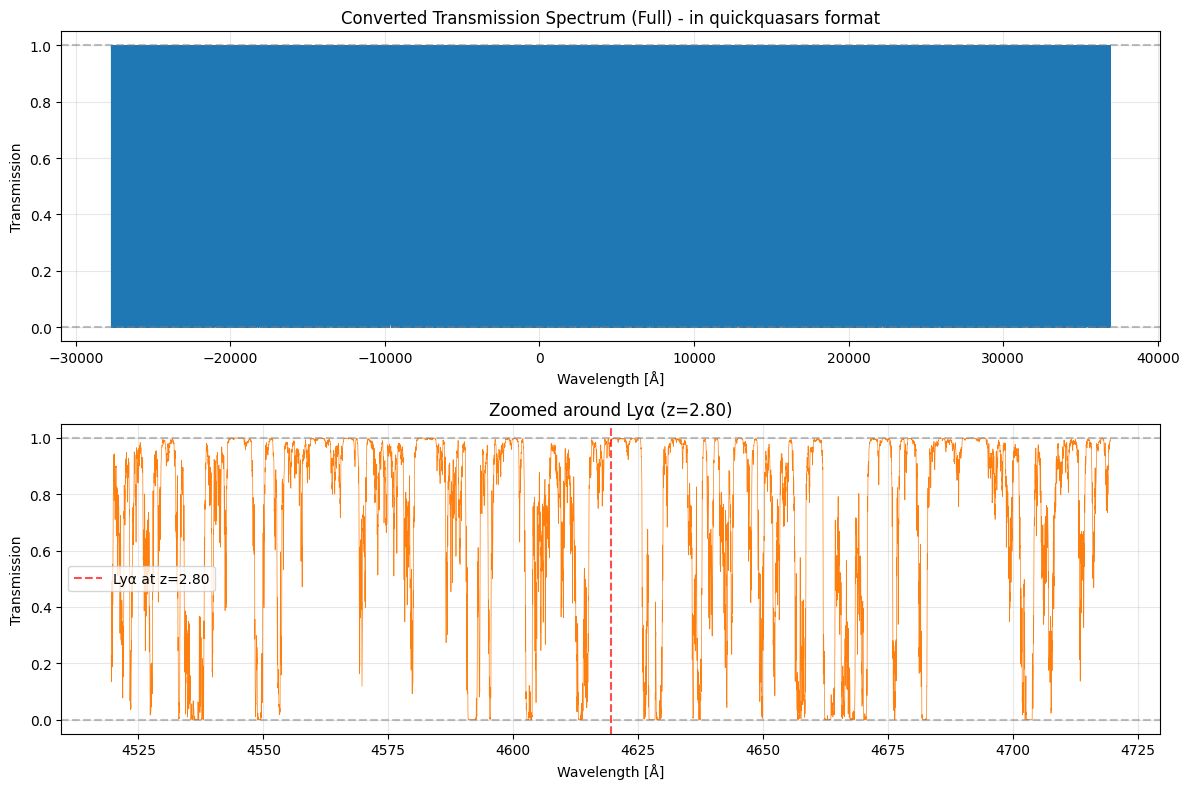

In [11]:
# 4. VISUALIZE THE CONVERTED DATA
# ============================================================================

# Plot the converted transmission vs wavelength
with fits.open(output_file) as hdul:
    wavelength = hdul['WAVELENGTH'].data
    transmission = hdul['TRANSMISSION'].data[0]  # First (and only) spectrum

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Full spectrum
ax1.plot(wavelength, transmission, linewidth=0.5, color='C0')
ax1.set_xlabel('Wavelength [Å]')
ax1.set_ylabel('Transmission')
ax1.set_title('Converted Transmission Spectrum (Full) - in quickquasars format')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.axhline(y=1, color='gray', linestyle='--', alpha=0.5)

# Zoomed region around Lya
z = redshift[0]
lambda_lya = 1215.67
lambda_obs = lambda_lya * (1 + z)
window = 100  # Angstroms
mask = (wavelength > lambda_obs - window) & (wavelength < lambda_obs + window)

ax2.plot(wavelength[mask], transmission[mask], linewidth=0.5, color='C1')
ax2.axvline(x=lambda_obs, color='red', linestyle='--', alpha=0.7, 
            label=f'Lyα at z={z:.2f}')
ax2.set_xlabel('Wavelength [Å]')
ax2.set_ylabel('Transmission')
ax2.set_title(f'Zoomed around Lyα (z={z:.2f})')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [12]:
# 5. VERIFY COMPATIBILITY WITH QUICKQUASARS 
# ============================================================================

# Try to read it the way quickquasars would
print("Testing file with fitsio (used by quickquasars):")
print("="*60)

try:
    h = fitsio. FITS(output_file)
    
    # Check for required HDUs
    print("\nHDU names found:")
    for hdu in h:
        print(f"  - {hdu.get_extname()}")
    
    # Read wavelength
    if "WAVELENGTH" in h: 
        wave = h["WAVELENGTH"].read()
        print(f"\n✓ WAVELENGTH HDU:  shape={wave.shape}")
    else:
        print("\n✗ WAVELENGTH HDU not found!")
    
    # Read transmission
    if "TRANSMISSION" in h: 
        trans = h["TRANSMISSION"]. read()
        print(f"✓ TRANSMISSION HDU:  shape={trans.shape}")
    elif "F_LYA" in h:
        trans = h["F_LYA"].read()
        print(f"✓ F_LYA HDU: shape={trans.shape}")
    else:
        print("✗ TRANSMISSION/F_LYA HDU not found!")
    
    # Check shape compatibility
    if trans.shape[1] == wave.size:
        print(f"✓ Shapes are compatible:  trans[{trans.shape[0]}, {trans.shape[1]}] matches wave[{wave.size}]")
    else:
        print(f"✗ Shape mismatch: trans. shape[1]={trans.shape[1]} vs wave.size={wave.size}")
    
    # Read metadata
    if "METADATA" in h:
        meta = h["METADATA"].read()
        print(f"✓ METADATA HDU: {len(meta)} entries")
        print(f"  Columns:  {meta.dtype.names}")
        
        # Check required columns
        required_cols = ['MOCKID', 'RA', 'DEC', 'Z']
        for col in required_cols:
            if col in meta.dtype.names:
                print(f"  ✓ {col}: {meta[col][0]}")
            else:
                print(f"  ✗ {col}:  missing!")
    else:
        print("✗ METADATA HDU not found!")
    
    h.close()
    
    print("\n" + "="*60)
    print("✓ File format looks compatible with quickquasars!")
    
except Exception as e:
    print(f"\n✗ Error reading file with fitsio:")
    print(f"  {e}")
    import traceback
    traceback.print_exc()

Testing file with fitsio (used by quickquasars):

HDU names found:
  - 
  - METADATA
  - WAVELENGTH
  - TRANSMISSION

✓ WAVELENGTH HDU:  shape=(4194304,)
✓ TRANSMISSION HDU:  shape=(1, 4194304)
✓ Shapes are compatible:  trans[1, 4194304] matches wave[4194304]
✓ METADATA HDU: 1 entries
  Columns:  ('MOCKID', 'RA', 'DEC', 'Z', 'Z_noRSD')
  ✓ MOCKID: 39628501363461808
  ✓ RA: 164.83664707337022
  ✓ DEC: 30.909632811464526
  ✓ Z: 2.8

✓ File format looks compatible with quickquasars!


In [13]:
# 6. SUMMARY STATS
# ============================================================================

print("SUMMARY")
print("="*60)
print(f"Input file: {input_file}")
print(f"Output file: {output_file}")
print(f"")
print(f"Quasar properties:")
print(f"  RA:        {ra[0]}°")
print(f"  DEC:       {dec[0]}°")
print(f"  Redshift: {redshift[0]}")
print(f"  MOCKID:   {mockid_start}")
print(f"")
print(f"Next steps:")
print(f"1. If the conversion looks good, try running quickquasars:")
print(f"   quickquasars -i {output_file} --outdir test_output")
print(f"")
print(f"2. To convert multiple transmission files, use:")
print(f"   python convert_to_quickquasars_format.py \\")
print(f"       --input transmission_*. txt \\")
print(f"       --output transmission-16-12345.fits \\")
print(f"       --ra 150.0 151.0 ... \\")
print(f"       --dec 2.0 2.1 ...  \\")
print(f"       --redshift 2.2 2.2 ...")

SUMMARY
Input file: /pscratch/sd/m/mherbold/tests/P1D_Mocks/transmission_files/2-8/transmission_2-8_20251103_205009_4977.fits
Output file: test_transmission_20260120_150355.fits

Quasar properties:
  RA:        164.83664707337022°
  DEC:       30.909632811464526°
  Redshift: 2.8
  MOCKID:   39628501363461808

Next steps:
1. If the conversion looks good, try running quickquasars:
   quickquasars -i test_transmission_20260120_150355.fits --outdir test_output

2. To convert multiple transmission files, use:
   python convert_to_quickquasars_format.py \
       --input transmission_*. txt \
       --output transmission-16-12345.fits \
       --ra 150.0 151.0 ... \
       --dec 2.0 2.1 ...  \
       --redshift 2.2 2.2 ...


## Extend conversion to multiple transmission files

In [96]:
# Define sample / pool functions
# ============================================================================

def initialize_qso_pool(sample, seed=123):
    """
    (Re)initialize the QSO pool from the sample DataFrame.
    Call this before each conversion to get a fresh pool.
    """
    from collections import defaultdict
    import numpy as np
    
    qso_pool = defaultdict(list)
    for _, row in sample.iterrows():
        qso_pool[row["z_bin"]].append(row)
    
    # Shuffle each bin
    rng = np.random.default_rng(seed=seed)
    for zb in qso_pool:
        rng.shuffle(qso_pool[zb])
    
    return qso_pool

def sample_qso_for_redshift(z, qso_pool, rng=None):
    """
    Sample a QSO without removing it from the pool.
    Allows repeated use of the same pool.
    """
    if z not in qso_pool or len(qso_pool[z]) == 0:
        raise RuntimeError(f"No QSOs available for redshift bin z={z}")
    
    if rng is None:
        rng = np.random.default_rng()
    
    # Sample WITHOUT replacement from the pool
    idx = rng.choice(len(qso_pool[z]))
    return qso_pool[z][idx]

# Or if you want to ensure no duplicates across all conversions:
def sample_unique_qsos(z_bins, qso_pool, n_per_bin, seed=None):
    """
    Sample unique QSOs for all redshift bins at once.
    """
    rng = np.random.default_rng(seed=seed)
    sampled_qsos = []
    
    for z_bin in z_bins:
        if z_bin not in qso_pool:
            print(f"⚠ No QSOs for z={z_bin}")
            continue
            
        available = qso_pool[z_bin]
        n_sample = min(n_per_bin, len(available))
        
        # Sample indices without replacement
        indices = rng.choice(len(available), size=n_sample, replace=False)
        sampled_qsos.extend([available[i] for i in indices])
    
    return sampled_qsos

# -------------------- INITIALIZE FRESH POOL --------------------
qso_pool = initialize_qso_pool(sample, seed=123)

# -------------------- COLLECT FILES --------------------
random.seed(random_seed)
all_input_files = []
# ... rest of your code

In [97]:
# Check pool inventory (must be <= sample)
# ============================================================================
print("QSO Pool Inventory:")
total_available = 0
for z_bin in redshift_bins:
    count = len(qso_pool.get(z_bin, []))
    total_available += count
    status = "✓" if count >= n_per_bin else "✗"
    print(f"  z={z_bin}: {count} QSOs available {status}")

print(f"\nTotal QSOs available: {total_available}")
print(f"Total QSOs needed: {len(redshift_bins) * n_per_bin}")

if total_available < len(redshift_bins) * n_per_bin:
    print("\n⚠ WARNING: Not enough QSOs in pool!")
    print("   Run the pool initialization cell again or reduce n_per_bin")

QSO Pool Inventory:
  z=2.0: 10 QSOs available ✓
  z=2.2: 10 QSOs available ✓
  z=2.4: 10 QSOs available ✓
  z=2.6: 10 QSOs available ✓
  z=2.8: 10 QSOs available ✓
  z=3.0: 10 QSOs available ✓
  z=3.2: 10 QSOs available ✓
  z=3.4: 10 QSOs available ✓
  z=3.6: 10 QSOs available ✓
  z=3.8: 10 QSOs available ✓

Total QSOs available: 100
Total QSOs needed: 50


In [99]:
# MULTI-REDSHIFT TRANSMISSION CONVERSION
# ===================================================================

sys.path.append('.')
from convert_to_quickquasars_format import convert_transmission_to_quickquasars

# -------------------- RE-INITIALIZE QSO POOL --------------------
# IMPORTANT: Re-create the pool to avoid depletion issues
print("Initializing fresh QSO pool...")
qso_pool = defaultdict(list)
for _, row in sample.iterrows():
    qso_pool[row["z_bin"]].append(row)

# Shuffle each bin
rng_pool = np.random.default_rng(seed=123)
for zb in qso_pool:
    rng_pool.shuffle(qso_pool[zb])

print("Pool inventory:")
for zb in sorted(qso_pool.keys()):
    print(f"  z={zb}: {len(qso_pool[zb])} QSOs")

# -------------------- CONFIGURATION --------------------
base_path = '/pscratch/sd/m/mherbold/tests/P1D_Mocks/transmission_files/'
redshift_bins = [2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8]
n_per_bin = 5  # increase later
nside = 16
pixel = 12345
random_seed = 42

# Validate
if n_per_bin > 10:
    raise ValueError(f"n_per_bin ({n_per_bin}) exceeds pool size (10)")

# -------------------- COLLECT FILES --------------------
random.seed(random_seed)

all_input_files = []
all_ra = []
all_dec = []
all_redshift = []
all_mockid = []

print(f"\nCollecting {n_per_bin} files per redshift bin...")
for z_bin in redshift_bins:
    # Check pool availability first
    if z_bin not in qso_pool or len(qso_pool[z_bin]) < n_per_bin:
        print(f"  ⚠ z={z_bin}: Only {len(qso_pool.get(z_bin, []))} QSOs available, skipping")
        continue
    
    # Convert redshift to folder format
    z_int = int(z_bin)
    z_frac = int(round((z_bin - z_int) * 10))
    redshift_folder = f"{z_int}-{z_frac}"
    
    # Find transmission files
    pattern = f"{base_path}{redshift_folder}/transmission_*.fits"
    available_files = glob.glob(pattern)
    
    if not available_files:
        print(f"  ⚠ No transmission files in {redshift_folder}/")
        continue
    
    # Sample files
    n_sample = min(n_per_bin, len(available_files))
    selected_files = random.sample(available_files, n_sample)
    
    # Assign QSOs to files
    for input_file in selected_files:
        qso = pop_qso_for_redshift(z_bin, qso_pool)
        
        all_input_files.append(input_file)
        all_ra.append(qso["ra"])
        all_dec.append(qso["dec"])
        all_redshift.append(z_bin)
        all_mockid.append(int(qso["targetid"]))
    
    print(f"  ✓ z={z_bin}: {n_sample} files, {n_sample} QSOs assigned")

print(f"\nTotal: {len(all_input_files)} quasars")

# -------------------- CONVERT --------------------
if len(all_input_files) == 0:
    print("\n✗ No files to convert!")
else:
    timestamp = datetime.utcnow().strftime("%Y%m%d_%H%M%S")
    output_file = f"transmission-{nside}-{pixel}_{timestamp}.fits"
    
    print(f"\nConverting to: {output_file}")
    
    try:
        output = convert_transmission_to_quickquasars(
            input_files=all_input_files,
            output_file=output_file,
            ra_values=all_ra,
            dec_values=all_dec,
            redshift_values=all_redshift,
            mockid_start=min(all_mockid),
            nside=nside,
            pixel=pixel,
            healpix_nest=True
        )
        
        print(f"\n✓ Success! Output: {output}")
        
        # Quick verification
        from astropy.io import fits
        with fits.open(output) as hdul:
            print(f"\nOutput shape: {hdul['TRANSMISSION'].data.shape}")
            
    except Exception as e:
        print(f"\n✗ Failed: {e}")
        import traceback
        traceback.print_exc()

Initializing fresh QSO pool...
Pool inventory:
  z=2.0: 10 QSOs
  z=2.2: 10 QSOs
  z=2.4: 10 QSOs
  z=2.6: 10 QSOs
  z=2.8: 10 QSOs
  z=3.0: 10 QSOs
  z=3.2: 10 QSOs
  z=3.4: 10 QSOs
  z=3.6: 10 QSOs
  z=3.8: 10 QSOs

  ✓ z=2.0: 5 files, 5 QSOs assigned
  ✓ z=2.2: 5 files, 5 QSOs assigned
  ✓ z=2.4: 5 files, 5 QSOs assigned
  ✓ z=2.6: 5 files, 5 QSOs assigned
  ✓ z=2.8: 5 files, 5 QSOs assigned
  ✓ z=3.0: 5 files, 5 QSOs assigned
  ✓ z=3.2: 5 files, 5 QSOs assigned
  ✓ z=3.4: 5 files, 5 QSOs assigned
  ✓ z=3.6: 5 files, 5 QSOs assigned
  ✓ z=3.8: 5 files, 5 QSOs assigned

Total: 50 quasars

Converting to: transmission-16-12345_20260120_181440.fits
Reading 50 transmission files...
Found velocity spacing: dv = 1.0 km/s
Found Lya wavelength: λ_0 = 1216 Å
Transmission array shape: (50, 4194304)
Wavelength range: -28432.3 - 37917.1 Å
Mean transmission: 0.6980

Writing output to transmission-16-12345_20260120_181440.fits
Done!

✓ Success! Output: transmission-16-12345_20260120_181440.fits

O

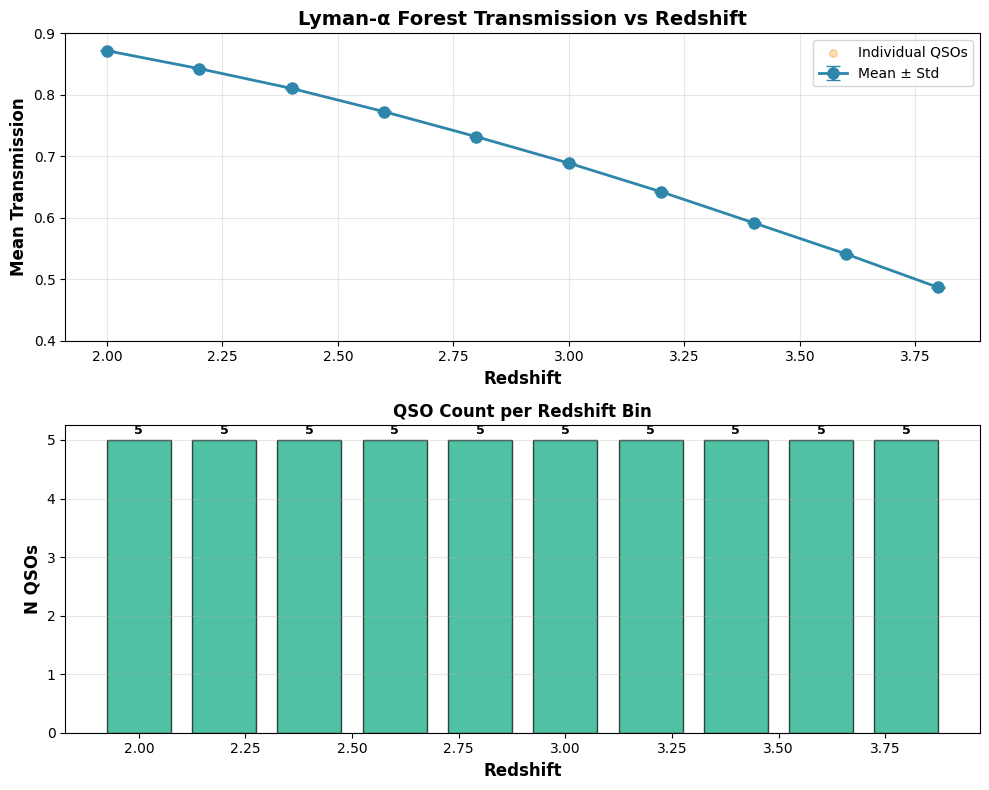


TRANSMISSION STATISTICS BY REDSHIFT
Redshift   N_QSOs     Mean         Std         
------------------------------------------------------------
2.0        5          0.871742     0.001104    
2.2        5          0.842569     0.000311    
2.4        5          0.810372     0.000348    
2.6        5          0.772652     0.000550    
2.8        5          0.731805     0.000315    
3.0        5          0.688916     0.000896    
3.2        5          0.642167     0.000929    
3.4        5          0.591757     0.000756    
3.6        5          0.541031     0.000206    
3.8        5          0.486609     0.000381    
------------------------------------------------------------
TOTAL      50         0.697962    


In [109]:
# DIAGNOSTIC PLOT: Mean Transmission vs Redshift
# ===================================================================

# Point to your converted file
fits_file = output  # or specify the filename directly

# Read the data
with fits.open(fits_file) as hdul:
    metadata = Table.read(hdul['METADATA'])
    transmission = hdul['TRANSMISSION'].data

# Calculate mean transmission for each quasar
mean_trans_per_qso = np.mean(transmission, axis=1)

# Get statistics per redshift bin
unique_z = np.unique(metadata['Z'])
z_bins = []
mean_trans = []
std_trans = []
n_qsos = []

for z in unique_z:
    mask = metadata['Z'] == z
    trans_at_z = mean_trans_per_qso[mask]
    
    z_bins.append(z)
    mean_trans.append(np.mean(trans_at_z))
    std_trans.append(np.std(trans_at_z))
    n_qsos.append(np.sum(mask))

z_bins = np.array(z_bins)
mean_trans = np.array(mean_trans)
std_trans = np.array(std_trans)

# Create plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Top: Mean transmission vs redshift
ax1.errorbar(z_bins, mean_trans, yerr=std_trans, 
             fmt='o-', markersize=8, linewidth=2, capsize=5,
             color='#2E86AB', label='Mean ± Std')
ax1.scatter(metadata['Z'], mean_trans_per_qso, 
           alpha=0.3, s=30, color='#F18F01', label='Individual QSOs')

ax1.set_xlabel('Redshift', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Transmission', fontsize=12, fontweight='bold')
ax1.set_title('Lyman-α Forest Transmission vs Redshift', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_ylim([0.4, 0.9])

# Bottom: Number of QSOs per bin
ax2.bar(z_bins, n_qsos, width=0.15, color='#06A77D', 
        edgecolor='black', alpha=0.7)
ax2.set_xlabel('Redshift', fontsize=12, fontweight='bold')
ax2.set_ylabel('N QSOs', fontsize=12, fontweight='bold')
ax2.set_title('QSO Count per Redshift Bin', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

for z, n in zip(z_bins, n_qsos):
    ax2.text(z, n + 0.1, str(n), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
# plt.savefig('transmission_diagnostic.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics
print("\n" + "="*60)
print("TRANSMISSION STATISTICS BY REDSHIFT")
print("="*60)
print(f"{'Redshift':<10} {'N_QSOs':<10} {'Mean':<12} {'Std':<12}")
print("-"*60)
for z, n, m, s in zip(z_bins, n_qsos, mean_trans, std_trans):
    print(f"{z:<10.1f} {n:<10d} {m:<12.6f} {s:<12.6f}")
print("-"*60)
print(f"{'TOTAL':<10} {len(metadata):<10d} {mean_trans_per_qso.mean():<12.6f}")
print("="*60)

## Compare to Other mocks

In [103]:
london_file = fitsio.FITS('/global/cfs/projectdirs/desi/mocks/lya_forest/london/lyacolore_skewers/v5.9/skewers-0/0/0/transmission-16-0.fits.gz')
# saclay_file = fitsio.FITS('/global/cfs/cdirs/desi/mocks/lya_forest/saclay/lya_skewers/v4.7/skewers-0/6/677/transmission-16-677.fits.gz')
new_file = fitsio.FITS('/pscratch/sd/m/mherbold/tests/P1D_Mocks/QQ_int/transmission-16-12345_20260120_181440.fits')

In [104]:
# COMPARE LONDON MOCK VS NEW CONVERTED FILE
# ============================================================================

print("="*80)
print("FILE STRUCTURE COMPARISON")
print("="*80)

print("\n--- LONDON MOCK ---")
for i, hdu in enumerate(london_file):
    extname = hdu.get_extname()
    print(f"  HDU {i}: {extname}")

print("\n--- NEW CONVERTED FILE ---")
for i, hdu in enumerate(new_file):
    extname = hdu.get_extname()
    print(f"  HDU {i}:  {extname}")

print("\n" + "="*80)
print("PRIMARY HEADER COMPARISON")
print("="*80)

print("\n--- LONDON MOCK PRIMARY HEADER ---")
london_primary = london_file[0].read_header()
for key in ['NSIDE', 'HPXNSIDE', 'PIXNUM', 'HPXPIXEL', 'HPXNEST', 'NESTED', 'SCHEME']:
    if key in london_primary:
        print(f"  {key}: {london_primary[key]}")
    else:
        print(f"  {key}: NOT FOUND")

print("\n--- NEW FILE PRIMARY HEADER ---")
new_primary = new_file[0]. read_header()
for key in ['NSIDE', 'HPXNSIDE', 'PIXNUM', 'HPXPIXEL', 'HPXNEST', 'NESTED', 'SCHEME']:
    if key in new_primary:
        print(f"  {key}: {new_primary[key]}")
    else:
        print(f"  {key}: NOT FOUND")

print("\n" + "="*80)
print("METADATA TABLE COMPARISON")
print("="*80)

print("\n--- LONDON MOCK METADATA ---")
if "METADATA" in london_file:
    london_meta = london_file["METADATA"]. read()
    print(f"  Number of entries: {len(london_meta)}")
    print(f"  Columns: {london_meta.dtype.names}")
    print(f"  First entry:")
    for col in ['MOCKID', 'RA', 'DEC', 'Z', 'Z_noRSD']: 
        if col in london_meta. dtype.names:
            print(f"    {col}: {london_meta[col][0]}")
        else:
            print(f"    {col}: NOT FOUND")
else:
    print("  METADATA HDU NOT FOUND")

print("\n--- NEW FILE METADATA ---")
if "METADATA" in new_file:
    new_meta = new_file["METADATA"]. read()
    print(f"  Number of entries: {len(new_meta)}")
    print(f"  Columns: {new_meta.dtype.names}")
    print(f"  First entry:")
    for col in ['MOCKID', 'RA', 'DEC', 'Z', 'Z_noRSD']:
        if col in new_meta.dtype.names:
            print(f"    {col}: {new_meta[col][0]}")
        else:
            print(f"    {col}: NOT FOUND")
else:
    print("  METADATA HDU NOT FOUND")

print("\n" + "="*80)
print("WAVELENGTH ARRAY COMPARISON")
print("="*80)

print("\n--- LONDON MOCK WAVELENGTH ---")
if "WAVELENGTH" in london_file:
    london_wave = london_file["WAVELENGTH"].read()
    print(f"  Shape: {london_wave.shape}")
    print(f"  Data type: {london_wave.dtype}")
    print(f"  Range: {london_wave.min():.2f} - {london_wave. max():.2f} Å")
    print(f"  Number of points: {len(london_wave)}")
    print(f"  First 5 values:  {london_wave[:5]}")
else:
    print("  WAVELENGTH HDU NOT FOUND")

print("\n--- NEW FILE WAVELENGTH ---")
if "WAVELENGTH" in new_file:
    new_wave = new_file["WAVELENGTH"].read()
    print(f"  Shape: {new_wave.shape}")
    print(f"  Data type: {new_wave. dtype}")
    print(f"  Range: {new_wave. min():.2f} - {new_wave.max():.2f} Å")
    print(f"  Number of points:  {len(new_wave)}")
    print(f"  First 5 values: {new_wave[:5]}")
else:
    print("  WAVELENGTH HDU NOT FOUND")

print("\n" + "="*80)
print("TRANSMISSION ARRAY COMPARISON")
print("="*80)

print("\n--- LONDON MOCK TRANSMISSION ---")
# Check for TRANSMISSION or F_LYA
trans_hdu_name = None
for name in ["TRANSMISSION", "F_LYA"]:
    if name in london_file:
        trans_hdu_name = name
        break

if trans_hdu_name:
    london_trans = london_file[trans_hdu_name].read()
    print(f"  HDU name: {trans_hdu_name}")
    print(f"  Shape: {london_trans.shape}")
    print(f"  Data type: {london_trans. dtype}")
    print(f"  Value range: {london_trans.min():.6f} - {london_trans. max():.6f}")
    print(f"  Mean: {london_trans.mean():.6f}")
    print(f"  Format: ({london_trans.shape[0]} quasars, {london_trans.shape[1]} wavelengths)")
else:
    print("  TRANSMISSION/F_LYA HDU NOT FOUND")

print("\n--- NEW FILE TRANSMISSION ---")
if "TRANSMISSION" in new_file:
    new_trans = new_file["TRANSMISSION"].read()
    print(f"  HDU name:  TRANSMISSION")
    print(f"  Shape: {new_trans. shape}")
    print(f"  Data type: {new_trans.dtype}")
    print(f"  Value range: {new_trans.min():.6f} - {new_trans.max():.6f}")
    print(f"  Mean: {new_trans.mean():.6f}")
    print(f"  Format: ({new_trans.shape[0]} quasars, {new_trans.shape[1]} wavelengths)")
else:
    print("  TRANSMISSION HDU NOT FOUND")

print("\n" + "="*80)
print("SHAPE COMPATIBILITY CHECK")
print("="*80)

if "WAVELENGTH" in london_file and trans_hdu_name: 
    london_wave_len = len(london_file["WAVELENGTH"].read())
    london_trans_shape = london_file[trans_hdu_name]. read().shape
    london_compatible = london_trans_shape[1] == london_wave_len
    print(f"\n--- LONDON MOCK ---")
    print(f"  Wavelength length: {london_wave_len}")
    print(f"  Transmission shape: {london_trans_shape}")
    print(f"  Compatible: {'✓ YES' if london_compatible else '✗ NO'}")

if "WAVELENGTH" in new_file and "TRANSMISSION" in new_file:
    new_wave_len = len(new_file["WAVELENGTH"].read())
    new_trans_shape = new_file["TRANSMISSION"].read().shape
    new_compatible = new_trans_shape[1] == new_wave_len
    print(f"\n--- NEW FILE ---")
    print(f"  Wavelength length: {new_wave_len}")
    print(f"  Transmission shape: {new_trans_shape}")
    print(f"  Compatible: {'✓ YES' if new_compatible else '✗ NO'}")

print("\n" + "="*80)
print("SUMMARY")
print("="*80)

# Check for critical differences
issues = []

# Check required HDUs
required_hdus = ["METADATA", "WAVELENGTH", "TRANSMISSION"]
for hdu_name in required_hdus: 
    if hdu_name not in new_file:
        issues.append(f"Missing required HDU: {hdu_name}")

# Check METADATA columns
if "METADATA" in new_file:
    new_meta = new_file["METADATA"].read()
    required_cols = ['MOCKID', 'RA', 'DEC', 'Z']
    for col in required_cols:
        if col not in new_meta.dtype.names:
            issues.append(f"Missing required METADATA column: {col}")

# Check shape compatibility
if "WAVELENGTH" in new_file and "TRANSMISSION" in new_file:
    if not new_compatible:
        issues.append("Wavelength and Transmission shapes are incompatible")

if len(issues) == 0:
    print("\n✓ No critical issues found!")
    print("  Your converted file appears to be compatible with quickquasars format.")
else:
    print("\n✗ Issues found:")
    for issue in issues:
        print(f"  - {issue}")

# Close files
london_file.close()
new_file.close()

FILE STRUCTURE COMPARISON

--- LONDON MOCK ---
  HDU 0: 
  HDU 1: METADATA
  HDU 2: WAVELENGTH
  HDU 3: F_LYA
  HDU 4: F_LYB
  HDU 5: F_METALS
  HDU 6: DLA

--- NEW CONVERTED FILE ---
  HDU 0:  
  HDU 1:  METADATA
  HDU 2:  WAVELENGTH
  HDU 3:  TRANSMISSION

PRIMARY HEADER COMPARISON

--- LONDON MOCK PRIMARY HEADER ---
  NSIDE: NOT FOUND
  HPXNSIDE: NOT FOUND
  PIXNUM: NOT FOUND
  HPXPIXEL: NOT FOUND
  HPXNEST: NOT FOUND
  NESTED: NOT FOUND
  SCHEME: NOT FOUND

--- NEW FILE PRIMARY HEADER ---
  NSIDE: 16
  HPXNSIDE: 16
  PIXNUM: 12345
  HPXPIXEL: 12345
  HPXNEST: True
  NESTED: True
  SCHEME: NEST

METADATA TABLE COMPARISON

--- LONDON MOCK METADATA ---
  Number of entries: 2577
  Columns: ('RA', 'DEC', 'Z', 'Z_noRSD', 'MOCKID')
  First entry:
    MOCKID: 59141
    RA: 44.93342971801758
    DEC: 4.62146520614624
    Z: 2.200377941131592
    Z_noRSD: 2.199108600616455

--- NEW FILE METADATA ---
  Number of entries: 50
  Columns: ('MOCKID', 'RA', 'DEC', 'Z', 'Z_noRSD')
  First entry:
   